In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/emperor47/rtw-sample-ab/RTW sample AB (1).csv


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:

folder_path = "/kaggle/input/datasets/emperor47/rtw-sample-ab"

files = os.listdir(folder_path)
print("Files inside folder:", files)

file_path = os.path.join(folder_path, files[0])

df = pd.read_csv(file_path)
df.head()

Files inside folder: ['RTW sample AB (1).csv']


,Claim No,Occurrence No,Claim Financial Year,Agency NN,Incident Date,Finalised Date,Total Paid,Paid Days Lost,Service Start Date,Service End Date,...,Mechanism,Nature,Major,Occupation,Gender,Date of Birth,Days to RTW,RTW Category,Age at Accident Date,Settled
0,13/005096,1,2013,7069,01/11/2012,24/01/2013,"$8,580.00",26.01,02/11/2012,18/12/2012,...,"Muscular stress-lift, carry, put down objects",Sprains and strains of joints and muscles,"Intermediate Clerical, Sales and Service Workers",Personal Care Assistant,Male,05/11/1956,46,RTW 13 Weeks,55,N
1,21/013033,1,2021,63246,29/04/2021,10/06/2021,$573.66,2,29/04/2021,30/04/2021,...,Falls on the same level,Open wound not including traumatic amputation,"Intermediate Clerical, Sales and Service Workers",Teachers Aide (Education Assistant),Female,18/08/1971,1,RTW 13 Weeks,49,N
2,16/005676,1,2016,2043954,16/11/2015,04/01/2016,$796.97,2.02,16/11/2015,17/11/2015,...,Being assaulted by a person or persons,Open wound not including traumatic amputation,Associate Professionals,Residential Care Officer,Male,07/07/1967,1,RTW 13 Weeks,48,N
3,15/002879,1,2015,63246,04/09/2014,18/02/2015,"$5,570.19",26,05/09/2014,10/10/2014,...,Muscular stress with no objects handled,Sprains and strains of joints and muscles,"Intermediate Clerical, Sales and Service Workers",Teachers Aide (Education Assistant),Male,29/07/1973,35,RTW 13 Weeks,41,N
4,14/020489,2,2014,63246,08/05/2014,29/01/2016,"$35,406.63",75.09,03/10/2014,12/01/2015,...,Falls on the same level,Sprains and strains of joints and muscles,Tradespersons and Related Workers,General Gardener,Male,06/02/1951,101,RTW 26 Weeks,63,N


In [5]:
df.shape

(23139, 25)

In [6]:
df.columns

Index(['Claim No', 'Occurrence No', 'Claim Financial Year', 'Agency NN',
       'Incident Date', 'Finalised Date', 'Total Paid', 'Paid Days Lost',
       'Service Start Date', 'Service End Date', 'Injury Agency Group',
       'Bodily Location Group', 'Mechanism Group', 'Nature Group',
       'Bodily Location', 'Mechanism', 'Nature', 'Major', 'Occupation',
       'Gender', 'Date of Birth', 'Days to RTW', 'RTW Category',
       'Age at Accident Date', 'Settled'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23139 entries, 0 to 23138
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Claim No               23139 non-null  object
 1   Occurrence No          23139 non-null  int64 
 2   Claim Financial Year   23139 non-null  int64 
 3   Agency NN              23139 non-null  int64 
 4   Incident Date          23139 non-null  object
 5   Finalised Date         23139 non-null  object
 6   Total Paid             23139 non-null  object
 7   Paid Days Lost         23139 non-null  object
 8   Service Start Date     22664 non-null  object
 9   Service End Date       22664 non-null  object
 10  Injury Agency Group    23139 non-null  object
 11  Bodily Location Group  23139 non-null  object
 12  Mechanism Group        23139 non-null  object
 13  Nature Group           23139 non-null  object
 14  Bodily Location        23139 non-null  object
 15  Mechanism          

In [8]:
df.isnull().sum()

Claim No                   0
Occurrence No              0
Claim Financial Year       0
Agency NN                  0
Incident Date              0
Finalised Date             0
Total Paid                 0
Paid Days Lost             0
Service Start Date       475
Service End Date         475
Injury Agency Group        0
Bodily Location Group      0
Mechanism Group            0
Nature Group               0
Bodily Location            0
Mechanism                  0
Nature                     0
Major                      0
Occupation                 0
Gender                     0
Date of Birth              1
Days to RTW                0
RTW Category               0
Age at Accident Date       0
Settled                    0
dtype: int64

In [9]:
# here there are perefect number of missing data in start and end of service data it , so there canbe a case that the claim is filed by people who never worked.

In [10]:
df.describe()

,Occurrence No,Claim Financial Year,Agency NN,Days to RTW,Age at Accident Date
count,23139.000000,23139.000000,2.313900e+04,23139.000000,23139.000000
mean,1.190760,2017.277972,1.215841e+06,150.411124,47.811401
std,0.589034,2.783048,1.149719e+06,265.220036,11.623734
min,1.000000,2013.000000,6.133000e+03,0.000000,15.000000
25%,1.000000,2015.000000,6.324600e+04,5.000000,40.000000
50%,1.000000,2017.000000,1.383309e+06,33.000000,49.000000
75%,1.000000,2020.000000,2.623843e+06,170.000000,57.000000
max,25.000000,2022.000000,2.663201e+06,3712.000000,114.000000


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df['Settled'].value_counts()

Settled
N    20261
Y     2878
Name: count, dtype: int64

In [13]:
#here for 1 Y there are approx 10 N so very high chance that model predicts N .

In [14]:
df.sample(5)

,Claim No,Occurrence No,Claim Financial Year,Agency NN,Incident Date,Finalised Date,Total Paid,Paid Days Lost,Service Start Date,Service End Date,...,Mechanism,Nature,Major,Occupation,Gender,Date of Birth,Days to RTW,RTW Category,Age at Accident Date,Settled
13323,20/012441,1,2020,2663017,28/02/2020,22/04/2020,"$2,940.41",7.26,28/02/2020,09/03/2020,...,Being assaulted by a person or persons,Open wound not including traumatic amputation,"Intermediate Clerical, Sales and Service Workers",Prison Officer,Male,30/04/1978,10,RTW 13 Weeks,41,N
18471,14/016631,1,2014,2182233,12/04/2014,08/08/2014,"$5,083.55",5,14/04/2014,02/05/2014,...,Being assaulted by a person or persons,Mental disorders,"Intermediate Clerical, Sales and Service Workers",Prison Officer,Male,17/02/1966,18,RTW 13 Weeks,48,N
21333,13/006195,1,2013,63246,06/11/2012,25/03/2013,$432.79,1,09/11/2012,09/11/2012,...,"Muscular stress-lift, carry, put down objects",Sprains and strains of joints and muscles,Professionals,Primary School Teacher,Female,12/12/1971,0,RTW 13 Weeks,40,N
15636,13/005003,1,2013,117828,23/10/2012,17/09/2014,"$15,900.43",25,01/07/2013,14/10/2013,...,"Muscular stress-lift, carry, put down objects","Disorders muscles, tendons, other soft tissue","Elementary Clerical, Sales and Service Workers",Caretaker,Female,04/06/1970,105,RTW 26 Weeks,42,N
10901,16/002986,1,2016,124623,15/09/2015,05/11/2015,"$1,009.48",2,16/09/2015,21/09/2015,...,Hitting stationary objects,Sprains and strains of joints and muscles,Professionals,Registered Nurse,Female,13/06/1971,5,RTW 13 Weeks,44,N


In [20]:
df['Total Paid'] = df['Total Paid'].str.replace('$', '', regex=False)
df['Total Paid'] = df['Total Paid'].str.replace(',', '', regex=False)

df['Total Paid'] = pd.to_numeric(df['Total Paid'], errors='coerce')

In [23]:
df.groupby('Settled')['Total Paid'].mean()

Settled
N     21758.082968
Y    179649.731254
Name: Total Paid, dtype: float64

there is a strong correlation between   #total paid   and   #settled   and   #rtw category   both the columns on which we have to predict our output. as the total paid amount increases the chances to settle also increases and if the total paid amount is high means the person was having and serious injury due to which rtw days also increases.

also the #age at accident column if the age is higher more time to recover hence rtw days increase

paid days lost is mostly same like total paid if paid days are more, more the chances of settled and as paid days are more means the person took more days to get recover hence rtw increases .

#Nature if the nature of the injury is light like a small cut or somwthing then rtw is less and if it is like a fracture rtw will increase

<Axes: xlabel='Settled', ylabel='count'>

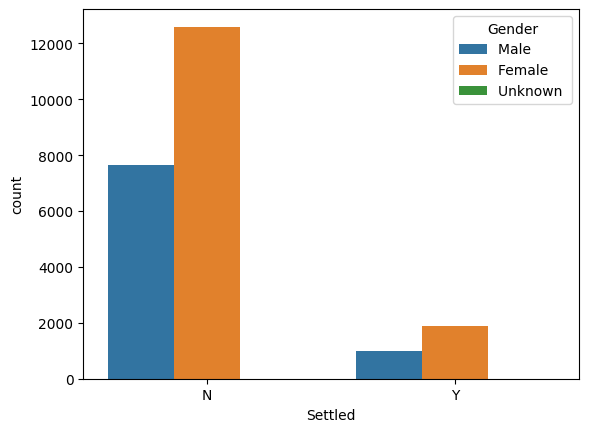

In [15]:
sns.countplot(x='Settled', hue='Gender', data=df)

In [16]:
# from the graph we can say that female have more chance of matter getting settled.

<Axes: xlabel='Claim Financial Year', ylabel='count'>

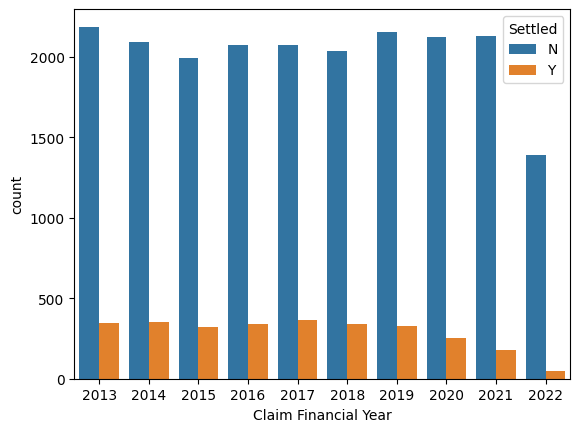

In [17]:
sns.countplot(data=df, x='Claim Financial Year', hue='Settled')

#from here we can say that clain year doenot depends that much its like moreover constant from 2013 to 2019 then its a dip after that